In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")

Ready


In [2]:
# 14 years of SPY for a robust test
df = yf.download("SPY", start="2010-01-01",
                 end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"].squeeze()
log_returns = np.log(price / price.shift(1)).dropna()

print(f"Loaded {len(price)} trading days")
print(f"Date range: {price.index[0].date()} to {price.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Loaded 3522 trading days
Date range: 2010-01-04 to 2023-12-29


In [5]:
# RSI(2) and SMA(200)
rsi2 = compute_rsi(price, period=2)
sma200 = price.rolling(200).mean()

# Without trend filter
buy_raw = (rsi2 < 10).astype(int)
sell_raw = (rsi2 > 90).astype(int)

# With trend filter - only buy in uptrend
buy_filtered = ((rsi2 < 10) & (price > sma200)).astype(int)
sell_filtered = ((rsi2 > 90) | (price < sma200)).astype(int)

print(f"RSI(2) stats:")
print(f" Buy signals (raw) : {buy_raw.sum()}")
print(f" Buy signals (filtered) : {buy_filtered.sum()}")
print(f" Signals removed by filter: {buy_raw.sum() - buy_filtered.sum()}")
print(f"  % signals filtered out : {(1 - buy_filtered.sum()/buy_raw.sum()):.1%}")

RSI(2) stats:
 Buy signals (raw) : 329
 Buy signals (filtered) : 202
 Signals removed by filter: 127
  % signals filtered out : 38.6%


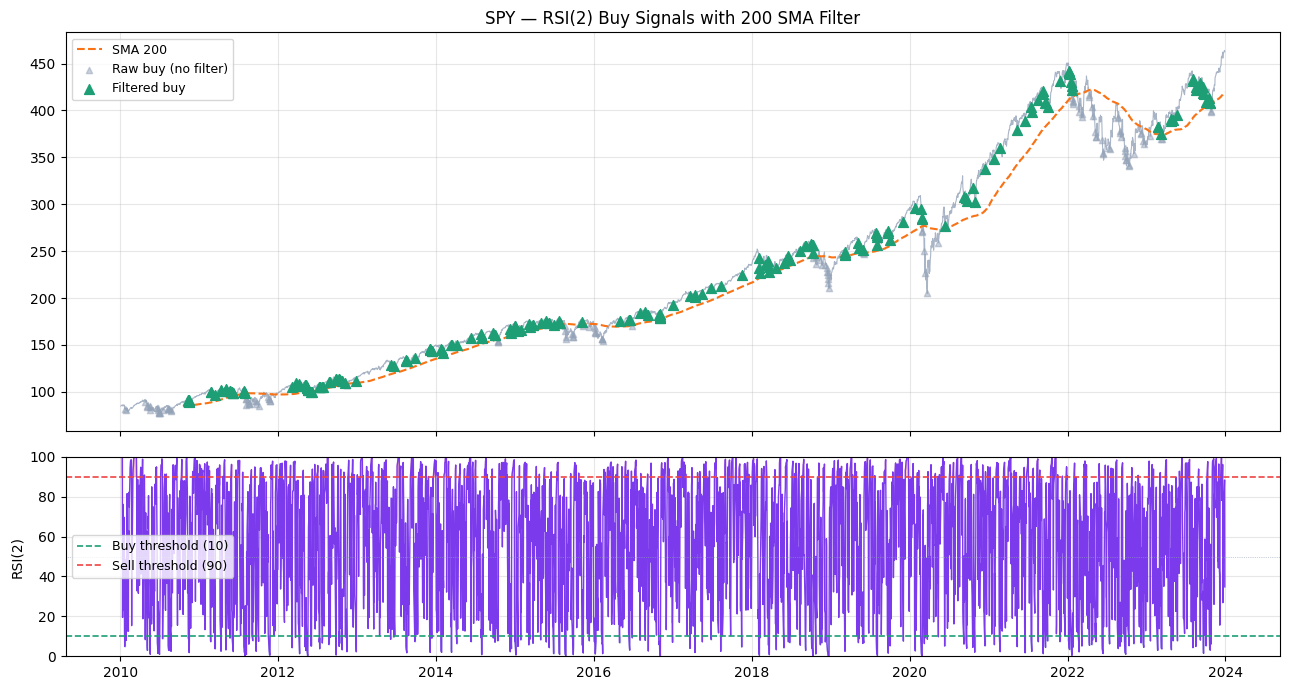

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Panel 1: Price with signals
ax1.plot(price,  color='#94a3b8', lw=0.8, alpha=0.8)
ax1.plot(sma200, color='#f97316', lw=1.5,
         linestyle='--', label='SMA 200')

# Raw buy signals
raw_buys = price[buy_raw == 1]
ax1.scatter(raw_buys.index, raw_buys,
            color='#94a3b8', marker='^', s=20,
            alpha=0.5, label='Raw buy (no filter)')

# Filtered buy signals
filt_buys = price[buy_filtered == 1]
ax1.scatter(filt_buys.index, filt_buys,
            color='#1D9E75', marker='^', s=50,
            zorder=5, label='Filtered buy')

ax1.set_title('SPY — RSI(2) Buy Signals with 200 SMA Filter')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: RSI(2)
ax2.plot(rsi2, color='#7c3aed', lw=1)
ax2.axhline(10, color='#1D9E75', lw=1.2,
            linestyle='--', label='Buy threshold (10)')
ax2.axhline(90, color='#ef4444', lw=1.2,
            linestyle='--', label='Sell threshold (90)')
ax2.axhline(50, color='#94a3b8', lw=0.5, linestyle=':')
ax2.fill_between(rsi2.index, rsi2, 10,
                 where=(rsi2 < 10),
                 alpha=0.3, color='#1D9E75')
ax2.fill_between(rsi2.index, rsi2, 90,
                 where=(rsi2 > 90),
                 alpha=0.3, color='#ef4444')
ax2.set_ylabel('RSI(2)')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
def rsi2_backtest(price, use_filter=True, cost_pct=0.0006):
    """
    RSI(2) mean reversion backtest.
    use_filter=True adds 200 SMA trend filter.
    """
    log_ret = np.log(price / price.shift(1)).dropna()
    rsi2    = compute_rsi(price, period=2)
    sma200  = price.rolling(200).mean()

    # State machine
    pos_list, cp = [], 0
    for i in range(len(rsi2)):
        in_uptrend = price.iloc[i] > sma200.iloc[i]
        if cp == 0:
            if use_filter:
                if rsi2.iloc[i] < 10 and in_uptrend:
                    cp = 1
            else:
                if rsi2.iloc[i] < 10:
                    cp = 1
        elif cp == 1:
            if rsi2.iloc[i] > 90 or (use_filter and not in_uptrend):
                cp = 0
        pos_list.append(cp)

    position = pd.Series(pos_list,
                         index=rsi2.index).shift(1).fillna(0)
    trades   = position.diff().abs().fillna(0)
    lr       = log_ret.reindex(position.index).fillna(0)
    net_ret  = position * lr - trades * cost_pct
    equity   = (1 + net_ret).cumprod()

    ar = net_ret.mean() * 252
    av = net_ret.std()  * np.sqrt(252)
    sh = (ar - 0.02)   / av
    dd = (equity - equity.cummax()) / equity.cummax()

    return {
        "ann_ret" : ar,
        "ann_vol" : av,
        "sharpe"  : sh,
        "max_dd"  : dd.min(),
        "n_trades": int(trades.sum()),
        "time_mkt": position.mean(),
        "equity"  : equity,
        "net_ret" : net_ret
    }

# Run both versions
raw_result  = rsi2_backtest(price, use_filter=False)
filt_result = rsi2_backtest(price, use_filter=True)

# Buy and hold benchmark
lr_all = np.log(price / price.shift(1)).dropna()
bh_eq  = (1 + lr_all).cumprod()
bh_ar  = lr_all.mean() * 252
bh_av  = lr_all.std()  * np.sqrt(252)
bh_sh  = (bh_ar - 0.02) / bh_av
bh_dd  = ((bh_eq - bh_eq.cummax()) / bh_eq.cummax()).min()

print(f"\n{'='*62}")
print(f"  {'Strategy':<22} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9} {'Trades':>7}")
print(f"{'='*62}")
for name, r in [("RSI(2) No Filter", raw_result),
                ("RSI(2) + SMA200", filt_result)]:
    print(f"  {name:<22} {r['ann_ret']:>8.2%} {r['ann_vol']:>8.2%} {r['sharpe']:>7.2f} {r['max_dd']:>9.2%} {r['n_trades']:>7}")
print(f"  {'Buy & Hold':<22} {bh_ar:>8.2%} {bh_av:>8.2%} {bh_sh:>7.2f} {bh_dd:>9.2%} {'N/A':>7}")
print(f"{'='*62}")


  Strategy                Ann Ret  Ann Vol  Sharpe    Max DD  Trades
  RSI(2) No Filter          6.09%   14.20%    0.29   -32.61%     212
  RSI(2) + SMA200           4.24%    7.92%    0.28   -13.27%     168
  Buy & Hold               12.14%   17.38%    0.58   -35.75%     N/A


In [8]:
# Split: in-sample 2010-2018, out-of-sample 2018-2024
split_date = "2018-01-01"
price_is  = price[price.index < split_date]
price_oos = price[price.index >= split_date]

# Run on both periods
is_result  = rsi2_backtest(price_is,  use_filter=True)
oos_result = rsi2_backtest(price_oos, use_filter=True)

print(f"\n{'='*55}")
print(f"  WALK-FORWARD VALIDATION — RSI(2) + SMA200")
print(f"{'='*55}")
print(f"  {'Period':<20} {'Ann Ret':>8} {'Sharpe':>8} {'Max DD':>9}")
print(f"  {'-'*50}")
print(f"  {'In-Sample (2010-18)':<20} {is_result['ann_ret']:>8.2%} {is_result['sharpe']:>8.2f} {is_result['max_dd']:>9.2%}")
print(f"  {'Out-of-Sample(18-24)':<20} {oos_result['ann_ret']:>8.2%} {oos_result['sharpe']:>8.2f} {oos_result['max_dd']:>9.2%}")
print(f"{'='*55}")
sharpe_decay = (is_result['sharpe'] - oos_result['sharpe']) / abs(is_result['sharpe']) * 100
print(f"\n  Sharpe decay IS -> OOS: {sharpe_decay:.1f}%")
print(f"  {'ROBUST' if sharpe_decay < 50 else 'POSSIBLY OVERFIT'}")


  WALK-FORWARD VALIDATION — RSI(2) + SMA200
  Period                Ann Ret   Sharpe    Max DD
  --------------------------------------------------
  In-Sample (2010-18)     5.12%     0.45    -8.83%
  Out-of-Sample(18-24)    2.44%     0.06    -9.12%

  Sharpe decay IS -> OOS: 87.7%
  POSSIBLY OVERFIT


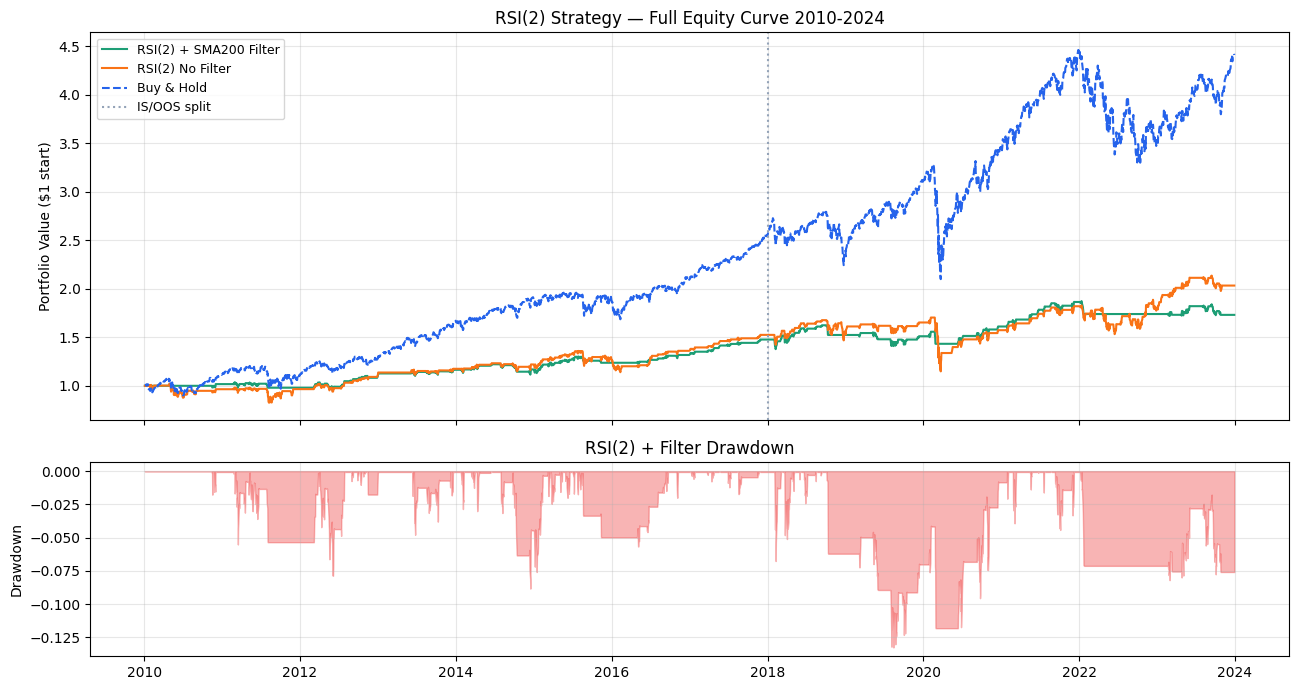

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Equity curves
ax1.plot(filt_result['equity'], color='#1D9E75',
         lw=1.5, label='RSI(2) + SMA200 Filter')
ax1.plot(raw_result['equity'],  color='#f97316',
         lw=1.5, label='RSI(2) No Filter')
ax1.plot(bh_eq, color='#2563eb', lw=1.5,
         linestyle='--', label='Buy & Hold')
ax1.axvline(pd.Timestamp(split_date), color='#94a3b8',
            lw=1.5, linestyle=':', label='IS/OOS split')
ax1.set_title('RSI(2) Strategy — Full Equity Curve 2010-2024')
ax1.set_ylabel('Portfolio Value ($1 start)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Drawdown
dd_filt = (filt_result['equity'] -
           filt_result['equity'].cummax()) / filt_result['equity'].cummax()
ax2.fill_between(dd_filt.index, dd_filt, 0,
                 color='#ef4444', alpha=0.4)
ax2.set_title('RSI(2) + Filter Drawdown')
ax2.set_ylabel('Drawdown')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import inspect

code = """import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import sys
sys.path.append("../utils")
from indicators import compute_rsi

""" + inspect.getsource(rsi2_backtest)

with open("../utils/rsi2_strategy.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Saved to utils/rsi2_strategy.py")